# Load and Explore

In [3]:
import pandas as pd

df = pd.read_csv('/content/groceries_data.csv')

df

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk
...,...,...,...
38760,4471,08-10-2014,sliced cheese
38761,2022,23-02-2014,candy
38762,1097,16-04-2014,cake bar
38763,1510,03-12-2014,fruit/vegetable juice


In [4]:
df.head()

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


In [5]:
df.isnull().sum()

,0
Member_number,0
Date,0
itemDescription,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38765 entries, 0 to 38764
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Member_number    38765 non-null  int64 
 1   Date             38765 non-null  object
 2   itemDescription  38765 non-null  object
dtypes: int64(1), object(2)
memory usage: 908.7+ KB


In [7]:
df.rename(columns={'itemDescription': 'Items'}, inplace=True)

In [8]:
df.shape

(38765, 3)

In [9]:
df.columns

Index(['Member_number', 'Date', 'Items'], dtype='object')

In [10]:
df.describe()

,Member_number
count,38765.000000
mean,3003.641868
std,1153.611031
min,1000.000000
25%,2002.000000
50%,3005.000000
75%,4007.000000
max,5000.000000


In [11]:
df.stack().value_counts(normalize=True)

,proportion
whole milk,0.021514
other vegetables,0.016321
rolls/buns,0.014756
soda,0.013019
yogurt,0.011471
...,...
1019,0.000017
1089,0.000017
1314,0.000017
preservation products,0.000009


In [12]:
sum(df.stack().value_counts(normalize=True))

1.0000000000000102

# Take Overview Of Frequency

<Axes: >

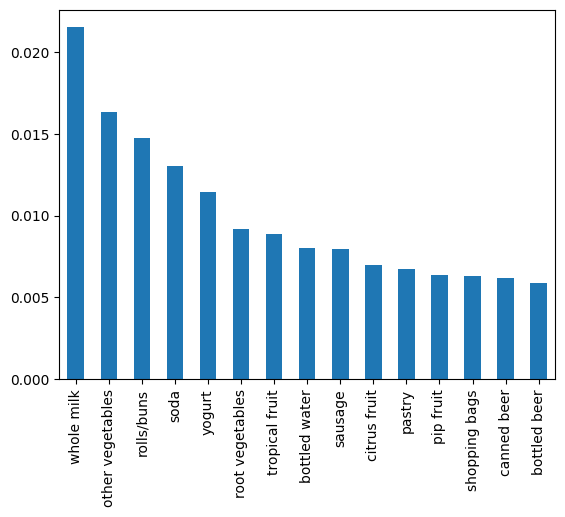

In [13]:
df.stack().value_counts(normalize=True)[:15].plot(kind='bar')  # relative frequency

<Axes: >

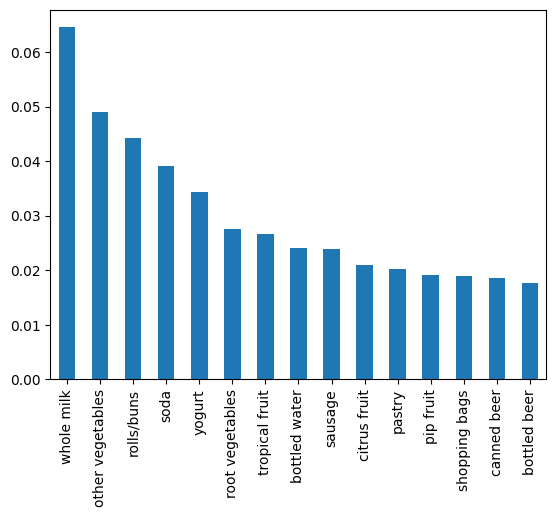

In [14]:
df.stack().value_counts().apply(lambda item: item / df.shape[0])[:15].plot(kind='bar')  # absolute frequency

In [19]:
grp_df = df.groupby('Member_number').agg({
    'Items':list,
    'Date':'first'}).reset_index()

grp_df

,Member_number,Items,Date
0,1000,"[soda, canned beer, sausage, sausage, whole mi...",27-05-2015
1,1001,"[frankfurter, frankfurter, beef, sausage, whol...",20-01-2015
2,1002,"[tropical fruit, butter milk, butter, frozen v...",26-04-2015
3,1003,"[sausage, root vegetables, rolls/buns, deterge...",10-02-2015
4,1004,"[other vegetables, pip fruit, root vegetables,...",02-12-2015
...,...,...,...
3893,4996,"[dessert, salty snack, rolls/buns, misc. bever...",24-10-2015
3894,4997,"[tropical fruit, white wine, whole milk, curd,...",27-12-2015
3895,4998,"[rolls/buns, curd]",14-10-2015
3896,4999,"[bottled water, butter milk, tropical fruit, b...",26-12-2015


In [20]:
grp_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3898 entries, 0 to 3897
Data columns (total 3 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Member_number  3898 non-null   int64 
 1   Items          3898 non-null   object
 2   Date           3898 non-null   object
dtypes: int64(1), object(2)
memory usage: 91.5+ KB


In [22]:
grp_df.isnull().sum()

,0
Member_number,0
Items,0
Date,0


# Split

In [32]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(grp_df, test_size=0.2)
train_df,test_df

(      Member_number                                              Items  \
 1493           2541  [newspapers, soda, frozen dessert, mayonnaise,...   
 748            1769  [rolls/buns, bottled beer, whole milk, canned ...   
 915            1938  [pork, tropical fruit, soda, tropical fruit, r...   
 546            1559  [beef, citrus fruit, sausage, napkins, semi-fi...   
 291            1301  [pot plants, sausage, pip fruit, soda, frozen ...   
 ...             ...                                                ...   
 2915           3994                              [soft cheese, onions]   
 1889           2944  [tropical fruit, sausage, beef, yogurt, bevera...   
 3727           4828  [sparkling wine, whole milk, rolls/buns, pork,...   
 3129           4214  [sausage, tropical fruit, long life bakery pro...   
 1710           2761  [citrus fruit, chocolate, pork, other vegetabl...   
 
             Date  
 1493  07-05-2014  
 748   30-12-2015  
 915   08-05-2015  
 546   03-10-2015 

In [33]:
train_df.columns

Index(['Member_number', 'Items', 'Date'], dtype='object')

In [34]:
train_df.head(6)

,Member_number,Items,Date
1493,2541,"[newspapers, soda, frozen dessert, mayonnaise,...",07-05-2014
748,1769,"[rolls/buns, bottled beer, whole milk, canned ...",30-12-2015
915,1938,"[pork, tropical fruit, soda, tropical fruit, r...",08-05-2015
546,1559,"[beef, citrus fruit, sausage, napkins, semi-fi...",03-10-2015
291,1301,"[pot plants, sausage, pip fruit, soda, frozen ...",03-11-2015
1876,2931,"[pip fruit, domestic eggs, seasonal products]",05-07-2014


# one-hot encoded

In [36]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
train_encode = te.fit_transform(train_df['Items'])
train_df_encoded_items = pd.DataFrame(train_encode, columns=te.columns_)

train_df_encoded_items.head()

,Instant food products,UHT-milk,abrasive cleaner,artif. sweetener,baby cosmetics,bags,baking powder,bathroom cleaner,beef,berries,...,turkey,vinegar,waffles,whipped/sour cream,whisky,white bread,white wine,whole milk,yogurt,zwieback
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,False,False,False,False,False,False


In [37]:
train_df_encoded_items.columns

Index(['Instant food products', 'UHT-milk', 'abrasive cleaner',
       'artif. sweetener', 'baby cosmetics', 'bags', 'baking powder',
       'bathroom cleaner', 'beef', 'berries',
       ...
       'turkey', 'vinegar', 'waffles', 'whipped/sour cream', 'whisky',
       'white bread', 'white wine', 'whole milk', 'yogurt', 'zwieback'],
      dtype='object', length=166)

In [39]:
final_df = pd.concat([train_df[['Member_number', 'Date']].reset_index(drop=True), train_df_encoded_items], axis=1)

In [40]:
final_df = final_df.drop(columns=['Member_number', 'Date'])

In [41]:
final_df.map(lambda x: isinstance(x,bool)).all().all()

np.True_

Use Of Apriori

In [45]:
from mlxtend.frequent_patterns import apriori

frequent_items = apriori(final_df, min_support=0.01, use_colnames=True)
frequent_items.head()

,support,itemsets
0,0.014753,(Instant food products)
1,0.080821,(UHT-milk)
2,0.030789,(baking powder)
3,0.120590,(beef)
4,0.076010,(berries)


# Use Of association

In [49]:
from mlxtend.frequent_patterns import association_rules

ass_freq = association_rules(frequent_items, metric="lift", min_threshold=1)
ass_freq.head()

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(beef),(UHT-milk),0.120590,0.080821,0.011546,0.095745,1.184650,1.0,0.001800,1.016504,0.177243,0.060811,0.016236,0.119301
1,(UHT-milk),(beef),0.080821,0.120590,0.011546,0.142857,1.184650,1.0,0.001800,1.025978,0.169574,0.060811,0.025320,0.119301
2,(bottled beer),(UHT-milk),0.152662,0.080821,0.015394,0.100840,1.247699,1.0,0.003056,1.022264,0.234292,0.070588,0.021780,0.145658
3,(UHT-milk),(bottled beer),0.080821,0.152662,0.015394,0.190476,1.247699,1.0,0.003056,1.046712,0.215980,0.070588,0.044627,0.145658
4,(bottled water),(UHT-milk),0.213278,0.080821,0.022130,0.103759,1.283817,1.0,0.004892,1.025594,0.281005,0.081368,0.024955,0.188784


In [51]:
ass_freq[ass_freq['confidence'] > 0.7].head(6)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
971,(curd cheese),(whole milk),0.013791,0.454779,0.010584,0.767442,1.687506,1.0,0.004312,2.344452,0.413107,0.023109,0.573461,0.395357
2066,"(beef, bottled beer)",(whole milk),0.019564,0.454779,0.013791,0.704918,1.550024,1.0,0.004894,1.847694,0.361930,0.029944,0.458785,0.367621
5000,"(cat food, yogurt)",(other vegetables),0.014432,0.376844,0.010263,0.711111,1.887017,1.0,0.004824,2.157078,0.476946,0.026936,0.536410,0.369173
5158,"(fruit/vegetable juice, chocolate)",(whole milk),0.015394,0.454779,0.011546,0.750000,1.649154,1.0,0.004545,2.180885,0.399783,0.025175,0.541471,0.387694
9842,"(other vegetables, pastry, bottled beer)",(whole milk),0.014432,0.454779,0.010584,0.733333,1.612506,1.0,0.004020,2.044580,0.385410,0.023077,0.510902,0.378303
10025,"(other vegetables, bottled water, brown bread)",(whole milk),0.016357,0.454779,0.011867,0.725490,1.595260,1.0,0.004428,1.986163,0.379348,0.025838,0.496517,0.375792


# Scatter Plot

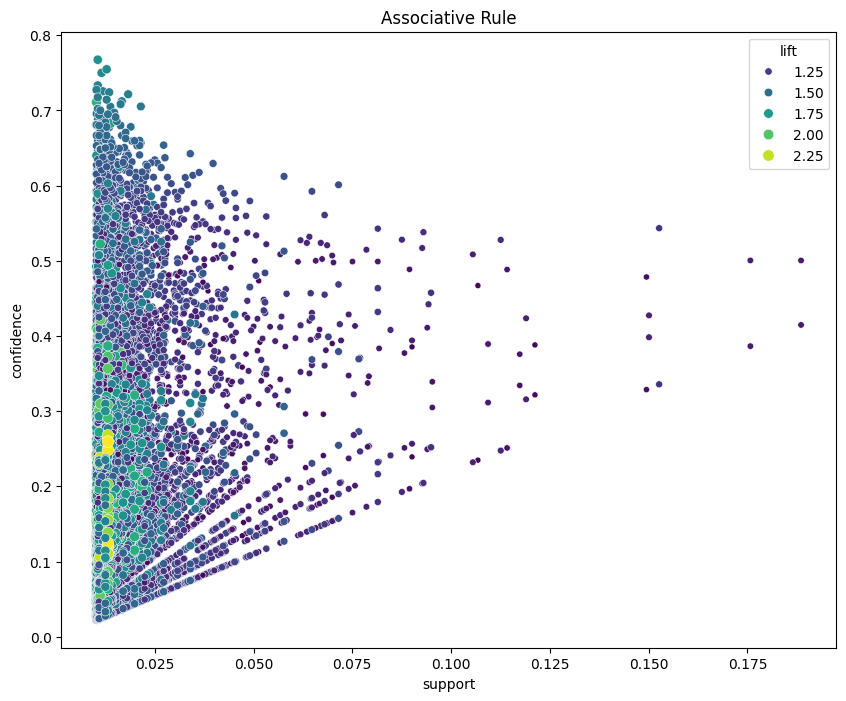

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.scatterplot(data=ass_freq, x='support', y='confidence', size='lift', hue='lift', palette='viridis')
plt.title('Associative Rule')
plt.show()

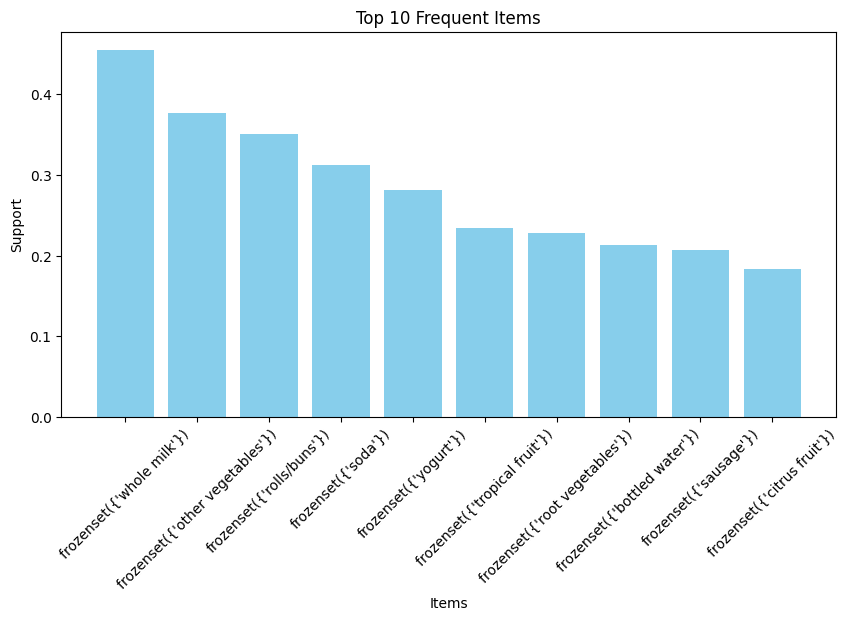

In [55]:
frequent_items['item_count'] = frequent_items['itemsets'].apply(lambda x: len(x))
top_items = frequent_items[frequent_items['item_count'] == 1].sort_values(by='support', ascending=False).head(10)

plt.figure(figsize=(10,5))
plt.bar(top_items['itemsets'].astype(str), top_items['support'], color='skyblue')
plt.xticks(rotation=45)
plt.title('Top 10 Frequent Items')
plt.xlabel('Items')
plt.ylabel('Support')
plt.show()


# ROC-AUC

In [56]:
from sklearn.metrics import roc_curve, precision_recall_curve, auc
import numpy as np

y_true = []
y_pred = []
confidences = []

y_true = np.array(y_true)
y_pred = np.array(y_pred)
confidences = np.array(confidences)